This notebook documents a test EEG analysis workflow using a publicly available dataset and MNE-Python.

In this project I explored how alpha activity changes between eyes-closed and eyes-open conditions using a small public EEG dataset.

I loaded the data, divided it into epochs, filtered it, and compared alpha-band power between the two conditions.

The main purpose was to understand each stage of the workflow in a Python environment. I used MNE-Python rather than MATLAB because it provides tools specifically designed for EEG analysis and gives me a useful foundation for developing this project further.

Through the final PSD analysis, I will investigate whether the results show a pattern consistent with the Berger effect.

[This paper](https://www.sciencedirect.com/science/article/pii/S1053811926000662) discusses the Berger effect in detail.


 

1. Import libraries and check the MNE version

In [ ]:
import mne
import numpy as np
import matplotlib.pyplot as plt

print(mne.__version__)

1.12.1


Next, I will load the EEG data and check the channel names. 

2. Load the EEG data

I am using a study that measured resting EEG signals of patients:
[EEG Alpha Waves Dataset report](https://hal.science/hal-02086581)
and
[Example code](https://github.com/plcrodrigues/Alpha-Waves-Dataset). Data from Patient_01 is selected for the analysis pipeline.

I will load the MATLAB file into a Python dictionary called newdict and check its keys. This shows where the data is stored inside the dictionary and what I need to extract for the analysis.



In [ ]:
from scipy.io import loadmat
from pathlib import Path

mat_path = Path("C:\\Users\\aryan\\OneDrive\\Documents\\EEG visualisation project\\Patient datasets\\subject_01.mat")
new_dict = loadmat(mat_path)
print(new_dict.keys())


dict_keys(['__header__', '__version__', '__globals__', 'SIGNAL'])


3. Inspect the data structure

I will now check what each column of the data matrix contains, and extract useful information such as the sampling interval and sampling frequency.

In [ ]:
signal = new_dict['SIGNAL']
print(type(signal))
print(signal.shape)
print(signal[:5, :]) 

<class 'numpy.ndarray'>
(119808, 19)
[[ 0.00000000e+00 -1.66397969e+04  1.07526416e+03  7.19751855e+03
   1.50166687e+03 -4.08049097e+03  8.72665344e+02 -7.44657080e+03
  -3.85217310e+03  1.03075305e+03 -8.91075488e+03  9.59378174e+02
  -2.18150317e+03  8.05414307e+03 -1.00511514e+04  1.32692959e+04
  -1.97763594e+04  0.00000000e+00  0.00000000e+00]
 [ 1.95312500e-03 -1.66351543e+04  1.07932727e+03  7.20429102e+03
   1.50618835e+03 -4.07948901e+03  8.77052429e+02 -7.44555273e+03
  -3.85025854e+03  1.03042834e+03 -8.90846875e+03  9.60230652e+02
  -2.17022876e+03  8.05955371e+03 -1.00660752e+04  1.32618818e+04
  -1.97789062e+04  0.00000000e+00  0.00000000e+00]
 [ 3.90625000e-03 -1.66370605e+04  1.07823169e+03  7.20582373e+03
   1.50503503e+03 -4.07830957e+03  8.84077454e+02 -7.44694043e+03
  -3.84817847e+03  1.03458240e+03 -8.90762891e+03  9.60583801e+02
  -2.17224731e+03  8.06309863e+03 -1.00636992e+04  1.32678223e+04
  -1.97734941e+04  0.00000000e+00  0.00000000e+00]
 [ 5.85937500e-03 

The signal.shape output tells us there are 19 columns as expected: 

Column 1 = time

Columns 2-17 = 16-channel EEG cap

Columns 18-19 = event metadata (eyes open or closed)

The dataset documentation states that columns 2–17 are recordings from the 16 electrodes. However, the physical units or calibration factors of the stored values are not specified. I will therefore treat the amplitudes as arbitrary dataset units.



In [ ]:
time = signal[:, 0]
eeg_data = signal[:, 1:17]
events = signal[:, 17:19]

print(f"Time shape: {time.shape}")
print(f"EEG shape: {eeg_data.shape}")
print(f"Events shape: {events.shape}")

dt = np.median(np.diff(time))
sampfreq = 1 / dt
duration = time[-1] - time[0]

print(f"Sampling interval: {dt:.6f} s")
print(f"Sampling frequency: {sampfreq:.2f} Hz")
print(f"Duration: {duration:.2f} s")
print(f"Duration: {duration / 60:.2f} min")

Time shape: (119808,)
EEG shape: (119808, 16)
Events shape: (119808, 2)
Sampling interval: 0.001953 s
Sampling frequency: 512.00 Hz
Duration: 234.00 s
Duration: 3.90 min


The frequency is consistent with the 512 Hz described in the experiment documentation.

Next I check that the time column is behaving as a regularly sampled time axis.

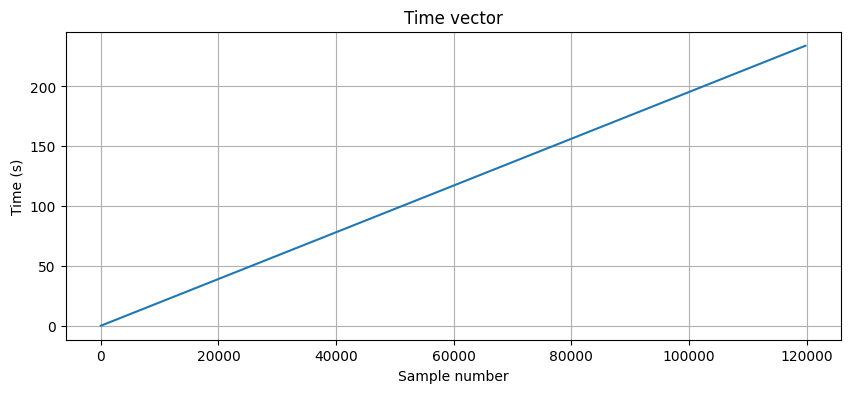

In [ ]:
plt.figure(figsize=(10, 4))
plt.plot(time)
plt.xlabel("Sample number")
plt.ylabel("Time (s)")
plt.title("Time vector")
plt.grid(True)
plt.show()

I have now verified the structure and format of the data. I must now change the format so that it usable within MNE, before being able to plot our EEG channels.

4. Plot EEG channels

I first convert the numpy ndarray 'signal' into a 'raw' array object so that MNE's inbuilt functions can be used directly on it.

In [ ]:
ch_names = [
    "FP1", "FP2", "FC5", "FC6",
    "FZ", "T7", "CZ", "T8",
    "P7", "P3", "PZ", "P4",
    "P8", "O1", "Oz", "O2"
]

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sampfreq,
    ch_types="eeg"
)

raw = mne.io.RawArray(data=eeg_data.T, info=info)

Creating RawArray with float64 data, n_channels=16, n_times=119808
    Range : 0 ... 119807 =      0.000 ...   233.998 secs
Ready.


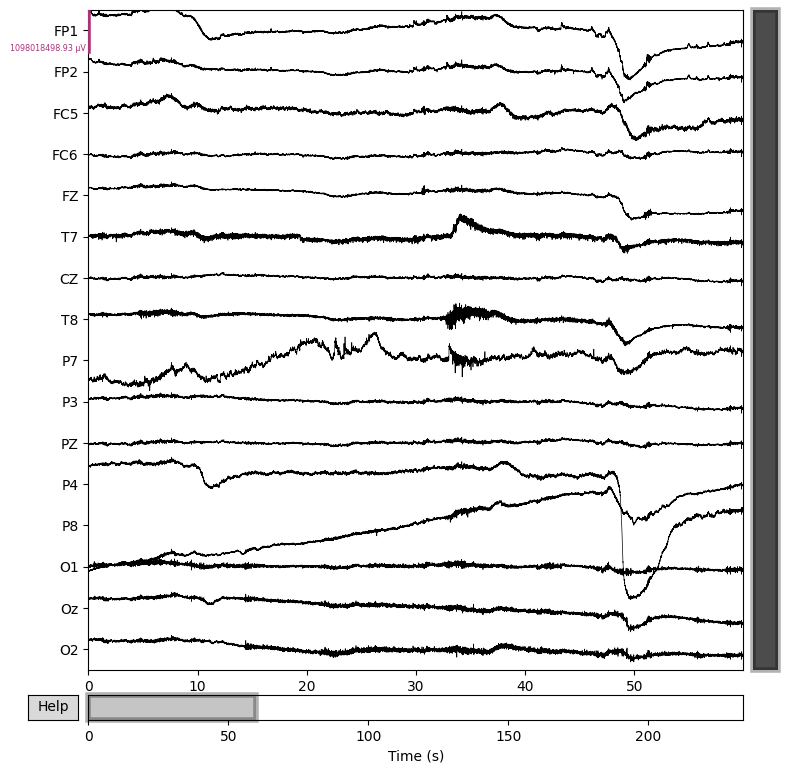

In [ ]:
_ = raw.plot(n_channels=16, duration=60, scalings="auto")


5. Create epochs

I now want to categorise the data by creating epochs around the event markers given in the data. 

Column 18 contains condition 1 triggers, corresponding to eyes-closed condition. Column 19 contains condition 2 triggers, corresponding to eyes-open condition. Each column is zero except for a value of one at the beginning of each relevant 10-second block.

In [ ]:

closed_trigger = events[:, 0]  
open_trigger = events[:, 1]   

closed_onsets = np.flatnonzero(closed_trigger == 1)
open_onsets = np.flatnonzero(open_trigger == 1)

print("Eyes-closed onset samples:")
print(closed_onsets)

print("\nEyes-open onset samples:")
print(open_onsets)

print("\nEyes-closed onset times (s):")
print(time[closed_onsets])

print("\nEyes-open onset times (s):")
print(time[open_onsets])

print(f"\nNumber of eyes-closed blocks: {len(closed_onsets)}")
print(f"Number of eyes-open blocks: {len(open_onsets)}")

Eyes-closed onset samples:
[ 35511  53413  69812  85802 101416]

Eyes-open onset samples:
[ 45179  61886  78140  93556 109193]

Eyes-closed onset times (s):
[ 69.35742188 104.32226563 136.3515625  167.58203125 198.078125  ]

Eyes-open onset times (s):
[ 88.24023438 120.87109375 152.6171875  182.7265625  213.26757813]

Number of eyes-closed blocks: 5
Number of eyes-open blocks: 5


This shows that there are 5 alternating eyes-open and eyes-closed segments. The blocks each appear to be around 15 seconds apart.

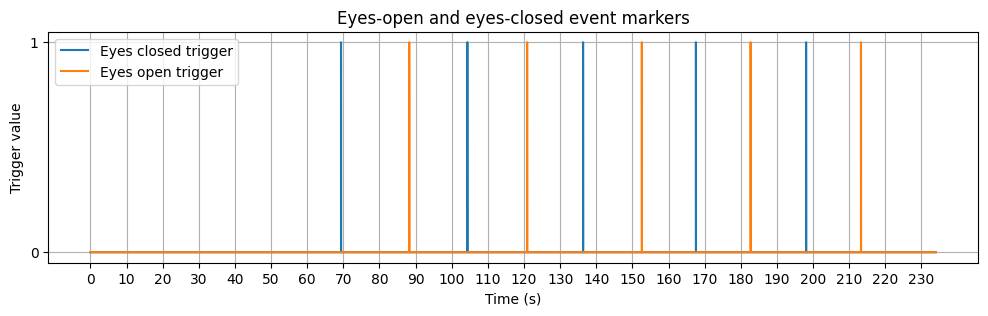

In [ ]:
plt.figure(figsize=(12, 3))

plt.plot(time, closed_trigger, label="Eyes closed trigger")
plt.plot(time, open_trigger, label="Eyes open trigger")

plt.xlabel("Time (s)")
plt.ylabel("Trigger value")
plt.title("Eyes-open and eyes-closed event markers")
plt.yticks([0, 1])
plt.xticks(np.arange(0, time[-1], step=10))
plt.legend()
plt.grid(True)
plt.show()

Now, I need to create an MNE events array in the required format: [sample index, previous value, event code]. This is then used with the MNE epoch method to create an epoched array.

In [ ]:

closed_events = np.column_stack([
    closed_onsets,
    np.zeros(len(closed_onsets), dtype=int),
    np.ones(len(closed_onsets), dtype=int)
])

open_events = np.column_stack([
    open_onsets,
    np.zeros(len(open_onsets), dtype=int),
    np.full(len(open_onsets), 2, dtype=int)
])


mne_events = np.vstack([closed_events, open_events])
mne_events = mne_events[np.argsort(mne_events[:, 0])]

event_id = {
    "eyes_closed": 1,
    "eyes_open": 2
}

print("MNE events array:")
print(mne_events)

print("\nEvent ID:")
print(event_id)

MNE events array:
[[ 35511      0      1]
 [ 45179      0      2]
 [ 53413      0      1]
 [ 61886      0      2]
 [ 69812      0      1]
 [ 78140      0      2]
 [ 85802      0      1]
 [ 93556      0      2]
 [101416      0      1]
 [109193      0      2]]

Event ID:
{'eyes_closed': 1, 'eyes_open': 2}


In [ ]:

epochs = mne.Epochs(
    raw=raw,
    events=mne_events,
    event_id=event_id,
    tmin=0,
    tmax=10 - 1 / sampfreq,
    baseline=None,
    preload=True,
    reject_by_annotation=False
)

print(epochs)

Not setting metadata
10 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 10 events and 5120 original time points ...
0 bad epochs dropped
<Epochs | 10 events (all good), 0 – 9.998 s (baseline off), ~6.3 MiB, data loaded,
 'eyes_closed': 5
 'eyes_open': 5>


I will now inspect the epoched waveforms and calculate channel amplitude ranges to identify any potentially flat, noisy, or otherwise poor-quality channels or epochs. If there is evidence of unusable data, it will be removed.

In [ ]:

epoch_data = epochs.get_data()

channel_ranges = np.ptp(epoch_data, axis=(0, 2))

for channel, amplitude_range in zip(epochs.ch_names, channel_ranges):
    print(f"{channel:>3s}: {amplitude_range:.6f} dataset units")

FP1: 2834.544922 dataset units
FP2: 1611.951965 dataset units
FC5: 3190.300781 dataset units
FC6: 925.203735 dataset units
 FZ: 2055.766602 dataset units
 T7: 1670.433166 dataset units
 CZ: 245.988281 dataset units
 T8: 1362.052246 dataset units
 P7: 4779.619385 dataset units
 P3: 660.325195 dataset units
 PZ: 539.122925 dataset units
 P4: 3224.694092 dataset units
 P8: 2493.999023 dataset units
 O1: 1236.126953 dataset units
 Oz: 1969.615234 dataset units
 O2: 3314.806640 dataset units


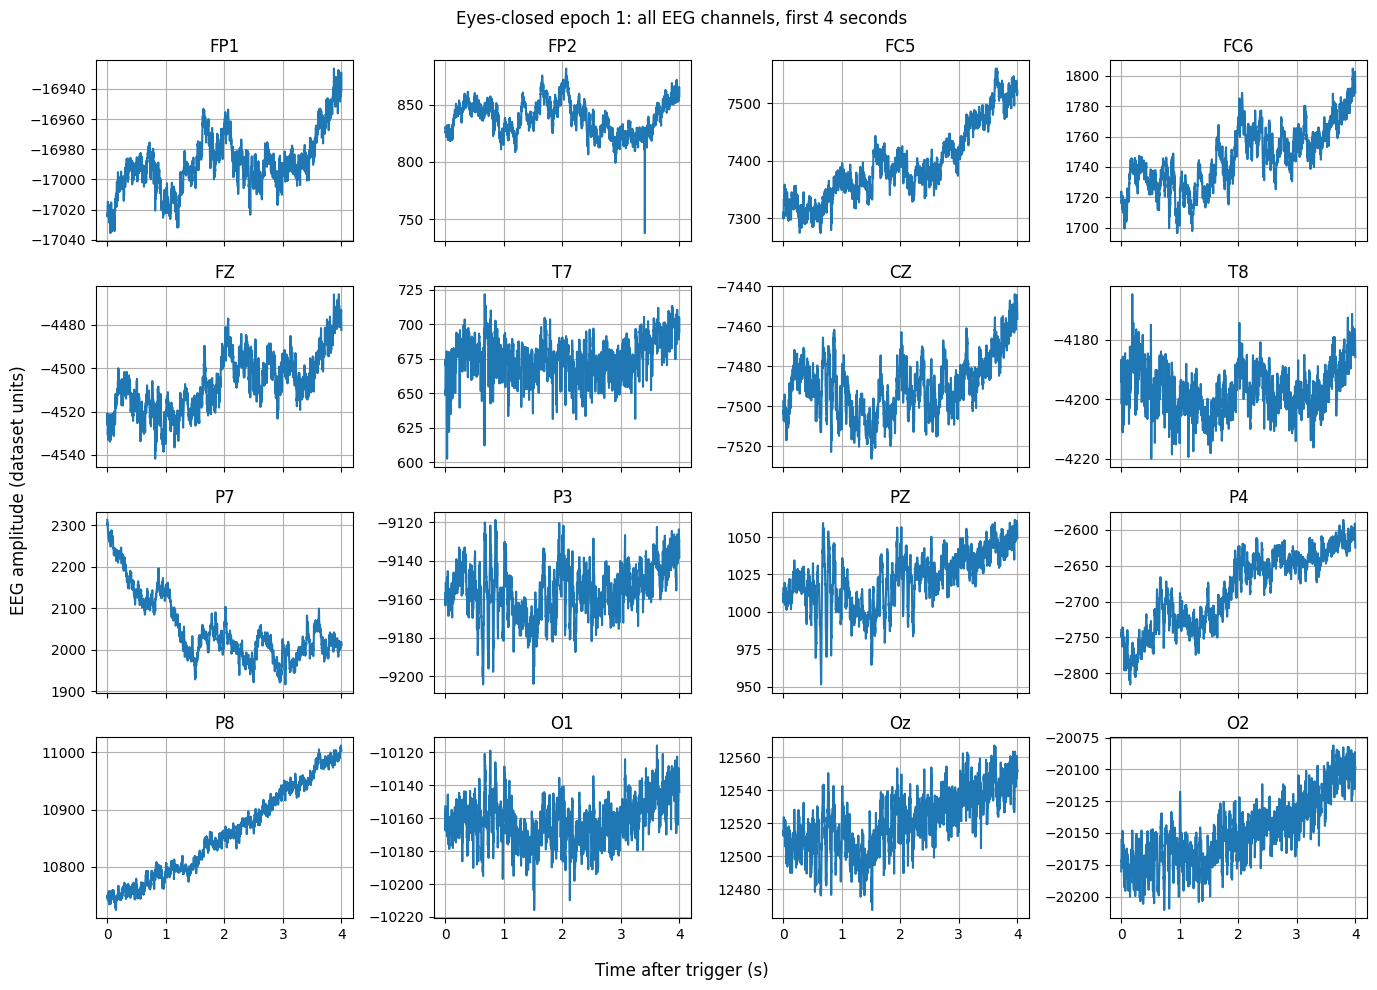

In [ ]:
closed_data = epochs["eyes_closed"].get_data()

time_mask = (epochs.times >= 0) & (epochs.times <= 4)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(14, 10),
    sharex=True
)

for channel_index, ax in enumerate(axes.ravel()):
    ax.plot(
        epochs.times[time_mask],
        closed_data[0, channel_index, time_mask]
    )
    ax.set_title(epochs.ch_names[channel_index])
    ax.grid(True)

fig.suptitle("Eyes-closed epoch 1: all EEG channels, first 4 seconds")
fig.supxlabel("Time after trigger (s)")
fig.supylabel("EEG amplitude (dataset units)")

plt.tight_layout()
plt.show()
plt.close()

Shown above is the eyes-closed condition. This was repeated for eyes-open condition. Most channels do not stand out as flat or drastically different from the others, which is a good sign. Our channels appear to have similar amplitude ranges and patterns during the eyes-closed condition for the first 4 seconds. However, several channels exhibit baseline drift, such as P8. In channel FP2, there is a potential transient artefact at 3.3 seconds. I now investigate the possible transient artefact, and verify if there is an issue with FP2.

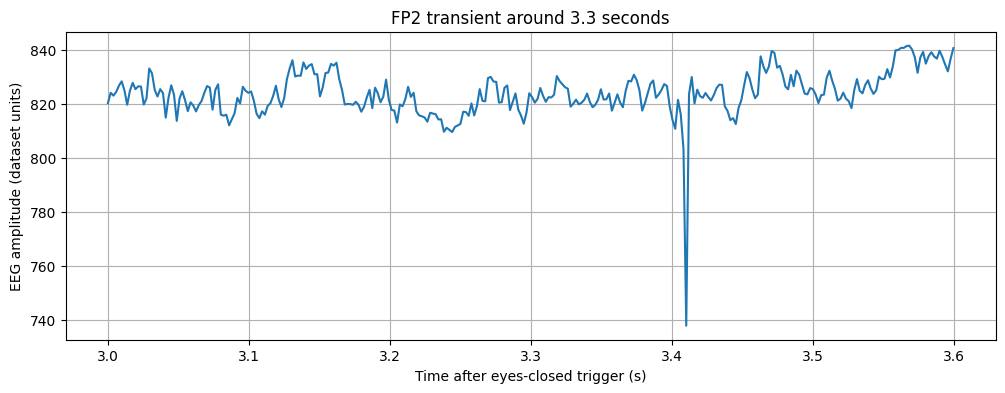

In [ ]:
fp2_index = epochs.ch_names.index("FP2")

# First eyes-closed epoch
fp2_data = epochs["eyes_closed"].get_data()[0, fp2_index, :]

zoom_mask = (
    (epochs.times >= 3.0) &
    (epochs.times <= 3.6)
)

plt.figure(figsize=(12, 4))

plt.plot(
    epochs.times[zoom_mask],
    fp2_data[zoom_mask]
)

plt.xlabel("Time after eyes-closed trigger (s)")
plt.ylabel("EEG amplitude (dataset units)")
plt.title("FP2 transient around 3.3 seconds")
plt.grid(True)

plt.show()
plt.close()

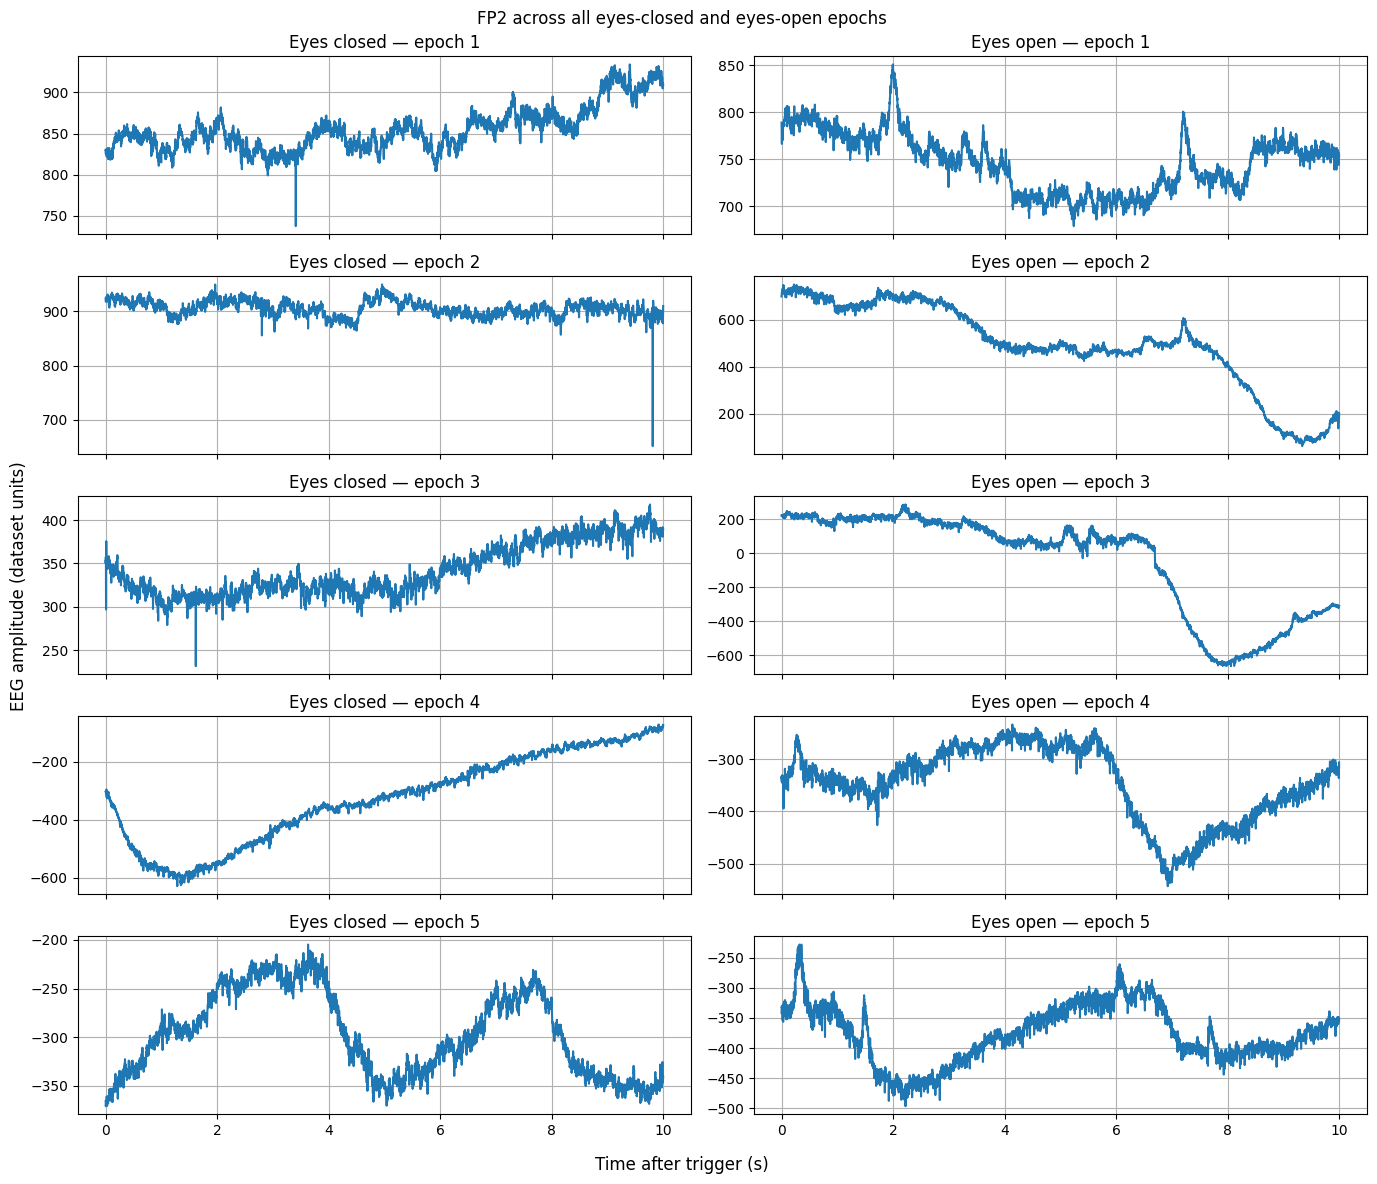

In [ ]:
closed_data = epochs["eyes_closed"].get_data()
open_data = epochs["eyes_open"].get_data()

fp2_index = epochs.ch_names.index("FP2")

fig, axes = plt.subplots(
    nrows=5,
    ncols=2,
    figsize=(14, 12),
    sharex=True
)

for epoch_index in range(5):
    # Eyes-closed FP2
    axes[epoch_index, 0].plot(
        epochs.times,
        closed_data[epoch_index, fp2_index, :]
    )
    axes[epoch_index, 0].set_title(
        f"Eyes closed — epoch {epoch_index + 1}"
    )
    axes[epoch_index, 0].grid(True)

    # Eyes-open FP2
    axes[epoch_index, 1].plot(
        epochs.times,
        open_data[epoch_index, fp2_index, :]
    )
    axes[epoch_index, 1].set_title(
        f"Eyes open — epoch {epoch_index + 1}"
    )
    axes[epoch_index, 1].grid(True)

fig.suptitle("FP2 across all eyes-closed and eyes-open epochs")
fig.supxlabel("Time after trigger (s)")
fig.supylabel("EEG amplitude (dataset units)")

plt.tight_layout()
plt.show()
plt.close()

There are several potential artefacts visible above. However, FP2 does not have a large amount of abnormal behaviour aside from the sudden spikes. Therefore, I will retain the channel, especially as it is not specifically involved in finding alpha-band power. A 1–40 Hz band-pass filter will be applied before alpha-band spectral analysis to remove slow drift, which will aid with alpha-power analysis.

6. Band-pass filter

To reduce slow drift and high-frequency noise before frequency-domain analysis, a 1–40 Hz band-pass filter will be applied.

The original epoched data will be kept unchanged. Filtering will be applied to a copy, allowing the preprocessed results to be compared with the original data if needed. The 8–12 Hz alpha range of interest lies within the retained frequency range after filtering.

In [ ]:
epochs_filtered = epochs.copy().filter(
    l_freq=1.0,
    h_freq=40.0
)

print(epochs_filtered)

Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1691 samples (3.303 s)

<Epochs | 10 events (all good), 0 – 9.998 s (baseline off), ~6.3 MiB, data loaded,
 'eyes_closed': 5
 'eyes_open': 5>


I will now use the same channel (FP2) to demonstrate the difference between the filtered and original waveforms. I must ensure that both datasets are plotted with the same scaling - this makes the two data sets more easily comparable.

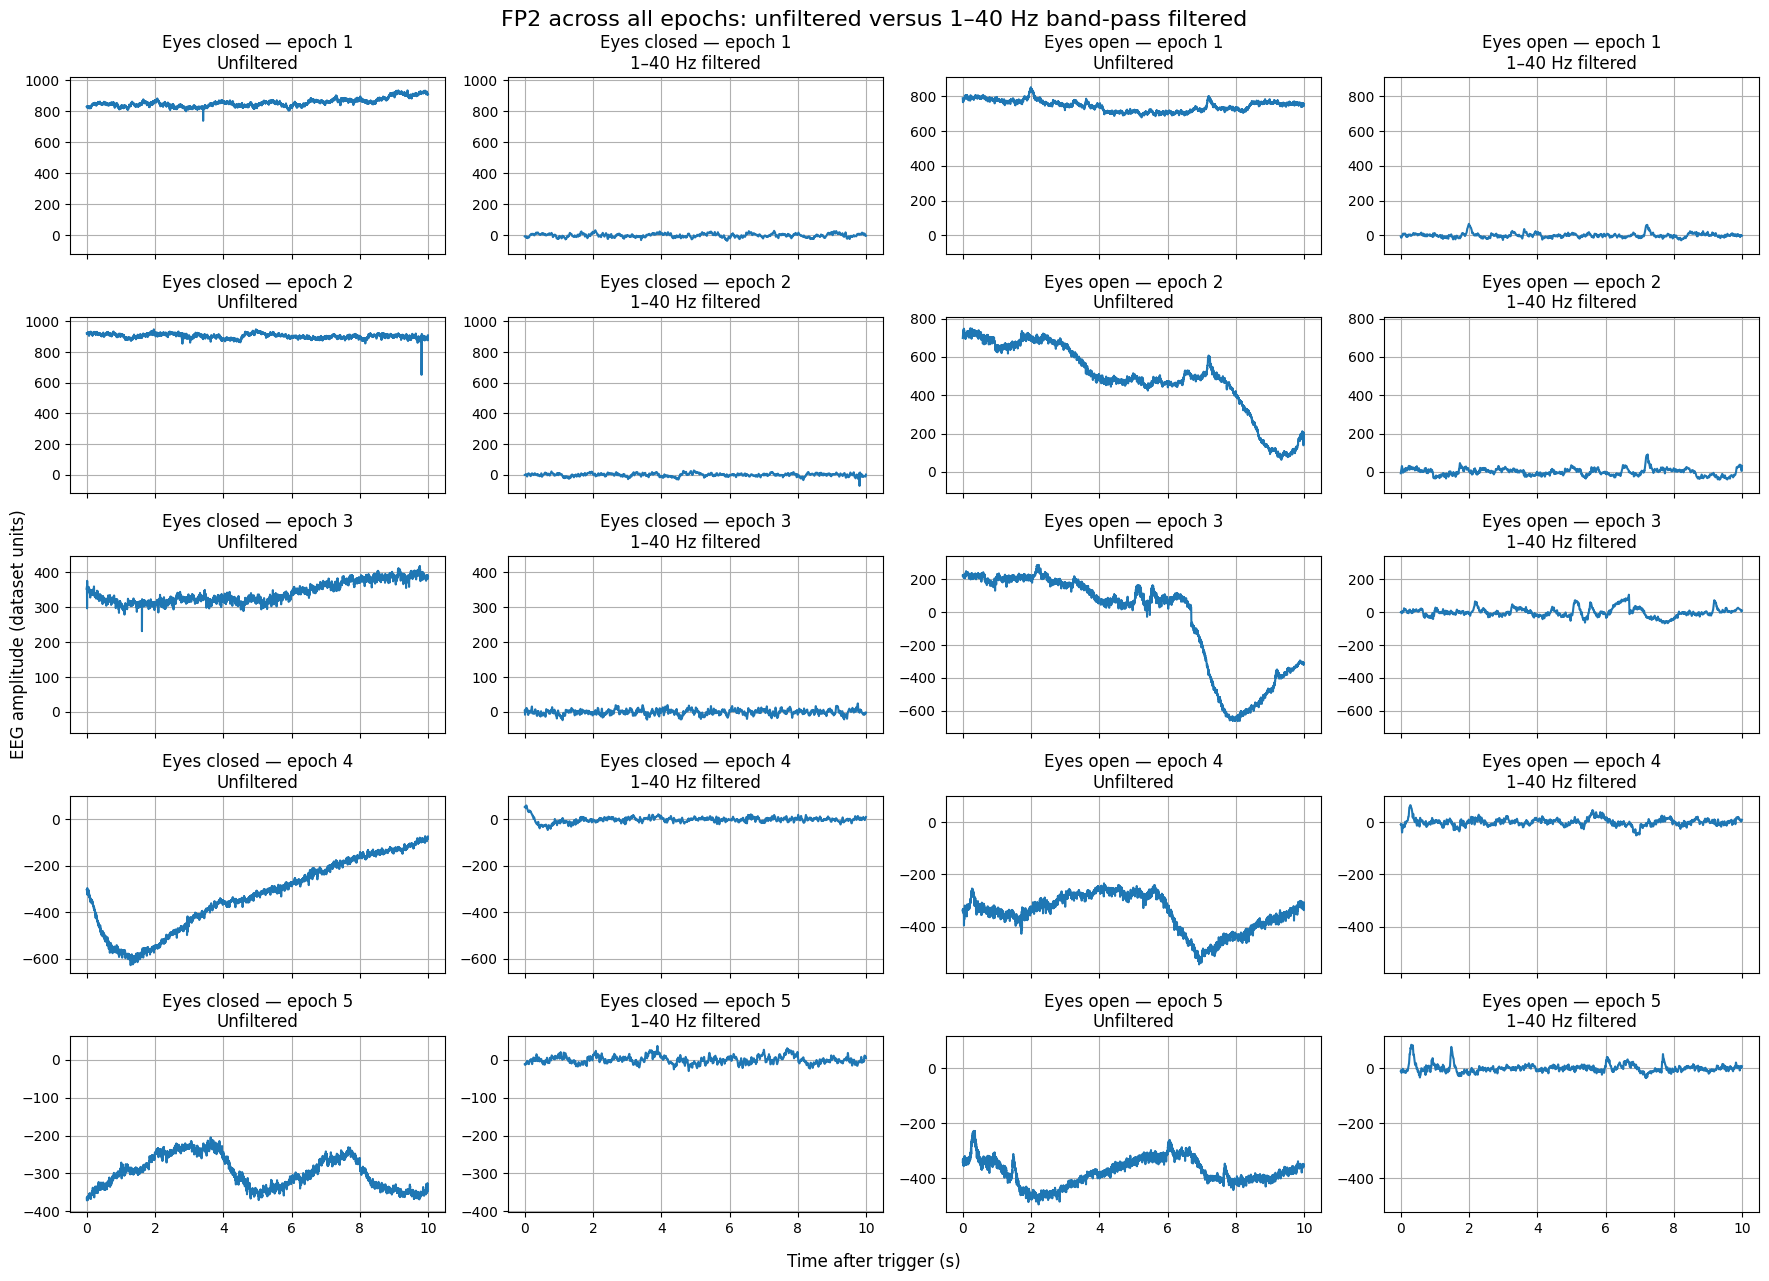

In [ ]:
# Find FP2 in the channel-name list
fp2_index = epochs.ch_names.index("FP2")

# Extract FP2 signals from original epochs
closed_fp2_original = epochs["eyes_closed"].get_data()[:, fp2_index, :]
open_fp2_original = epochs["eyes_open"].get_data()[:, fp2_index, :]

# Extract FP2 signals from filtered epochs
closed_fp2_filtered = epochs_filtered["eyes_closed"].get_data()[:, fp2_index, :]
open_fp2_filtered = epochs_filtered["eyes_open"].get_data()[:, fp2_index, :]

# Create a 5-row by 4-column figure
fig, axes = plt.subplots(
    nrows=5,
    ncols=4,
    figsize=(18, 13),
    sharex=True
)

for epoch_index in range(5):

    # Eyes closed: original and filtered
    axes[epoch_index, 0].plot(
        epochs.times,
        closed_fp2_original[epoch_index]
    )
    axes[epoch_index, 0].set_title(
        f"Eyes closed — epoch {epoch_index + 1}\nUnfiltered"
    )
    axes[epoch_index, 0].grid(True)

    axes[epoch_index, 1].plot(
        epochs_filtered.times,
        closed_fp2_filtered[epoch_index]
    )
    axes[epoch_index, 1].set_title(
        f"Eyes closed — epoch {epoch_index + 1}\n1–40 Hz filtered"
    )
    axes[epoch_index, 1].grid(True)

    # Eyes open: original and filtered
    axes[epoch_index, 2].plot(
        epochs.times,
        open_fp2_original[epoch_index]
    )
    axes[epoch_index, 2].set_title(
        f"Eyes open — epoch {epoch_index + 1}\nUnfiltered"
    )
    axes[epoch_index, 2].grid(True)

    axes[epoch_index, 3].plot(
        epochs_filtered.times,
        open_fp2_filtered[epoch_index]
    )
    axes[epoch_index, 3].set_title(
        f"Eyes open — epoch {epoch_index + 1}\n1–40 Hz filtered"
    )
    axes[epoch_index, 3].grid(True)

    # Match y-axis limits for the eyes-closed original/filter pair
    closed_values = np.concatenate([
        closed_fp2_original[epoch_index],
        closed_fp2_filtered[epoch_index]
    ])

    closed_min, closed_max = np.percentile(
        closed_values,
        [0.5, 99.5]
    )

    closed_padding = 0.1 * (closed_max - closed_min)

    axes[epoch_index, 0].set_ylim(
        closed_min - closed_padding,
        closed_max + closed_padding
    )
    axes[epoch_index, 1].set_ylim(
        closed_min - closed_padding,
        closed_max + closed_padding
    )

    # Match y-axis limits for the eyes-open original/filter pair
    open_values = np.concatenate([
        open_fp2_original[epoch_index],
        open_fp2_filtered[epoch_index]
    ])

    open_min, open_max = np.percentile(
        open_values,
        [0.5, 99.5]
    )

    open_padding = 0.1 * (open_max - open_min)

    axes[epoch_index, 2].set_ylim(
        open_min - open_padding,
        open_max + open_padding
    )
    axes[epoch_index, 3].set_ylim(
        open_min - open_padding,
        open_max + open_padding
    )

# Add figure-wide labels and display the figure
fig.suptitle(
    "FP2 across all epochs: unfiltered versus 1–40 Hz band-pass filtered",
    fontsize=16
)

fig.supxlabel("Time after trigger (s)")
fig.supylabel("EEG amplitude (dataset units)")

plt.tight_layout()
plt.show()
plt.close()

Above, the filtered data does not contain slow drifts over large amplitudes. Instead, the waveforms were much more consistently centered around zero. Some brief sharp transients were still visible, however many appear to be attenuated. They have been naturally removed during the filtering, although they were not necessarily identified as arterfacts. It is unclear whether they are artefacts, and if they were ocular or electrode-related.

7. PSD and alpha-band power analyses

Power spectral density analysis will help me to determine the relative contributions of alpha activity in the eyes-closed and eyes-open epochs to the total waveforms. I now expect there to be higher power in the 8–12 Hz alpha range in the eyes-closed epochs compared to the eyes-open epochs.

I should also expect the posterior and occipital regions to have the clearest increase in alpha power during the eyes-closed epochs. This is described by the Berger effect - alpha activity is strongest over the back of the scalp regions when the person is awake but relaxed with their eyes closed. This will be used as a guide when interpreting the results.

First, I compute the PSD for every epoch, channel and frequency bin spaced 0.5Hz apart. This is calculated by the frequency-bin spacing formula. 

Sampling frequency (512)/ number of samples per Fourier transform (1024)

This will allow a high enough fidelity to inspect the 8-12Hz alpha range.

I am using Welch's method within MNE, which divides the signal into shorter overlapping sections, and then averages the result toget a smooth estimate of the frequency content in the waveform.

In [ ]:
closed_psd_all = epochs_filtered["eyes_closed"].compute_psd(
    method="welch",
    fmin=1,
    fmax=40,
    n_fft=1024,
    n_overlap=512
)

open_psd_all = epochs_filtered["eyes_open"].compute_psd(
    method="welch",
    fmin=1,
    fmax=40,
    n_fft=1024,
    n_overlap=512
)

Effective window size : 2.000 (s)
Effective window size : 2.000 (s)


PSD was estimated separately for each epoch, channel, and frequency bin using Welch’s method. The five epoch-level PSD estimates were then averaged within each condition to produce one averaged PSD curve per channel. This now allows me to plot power against frequency for each channel.

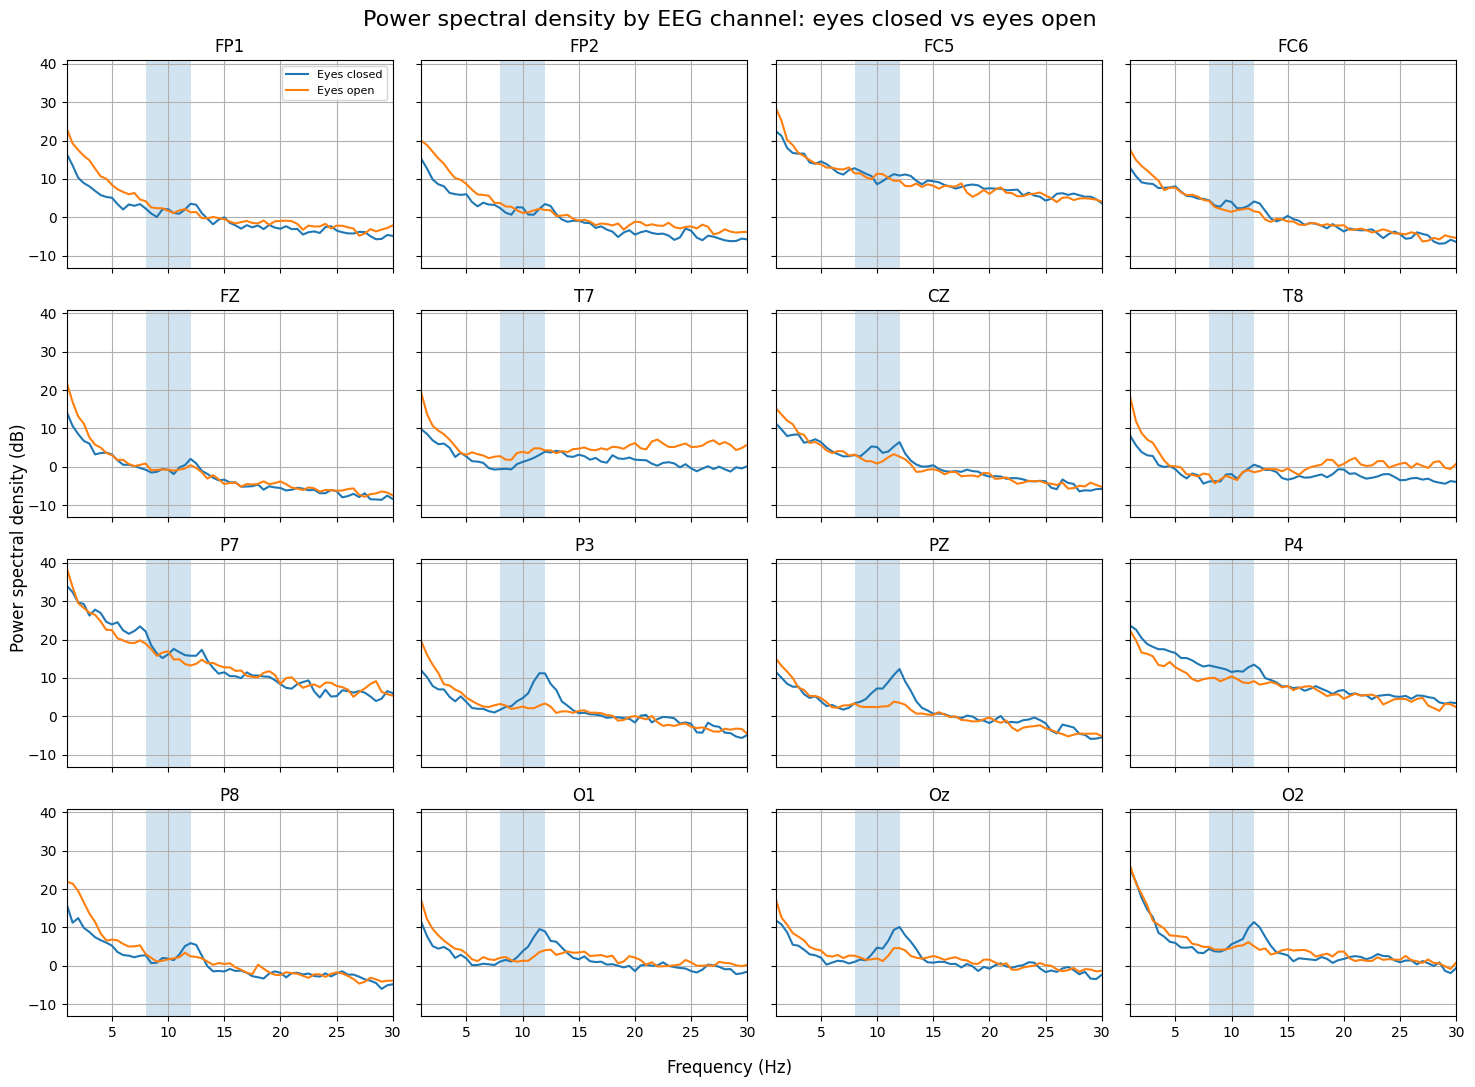

In [ ]:
closed_power, freqs = closed_psd_all.get_data(return_freqs=True)
open_power, _ = open_psd_all.get_data(return_freqs=True)

# Average across the five epochs in each condition
closed_mean = closed_power.mean(axis=0)  # shape: (16 channels, frequencies)
open_mean = open_power.mean(axis=0)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(15, 11),
    sharex=True,
    sharey=True
)

for channel_index, ax in enumerate(axes.ravel()):
    ax.plot(
        freqs,
        10 * np.log10(closed_mean[channel_index]),
        label="Eyes closed"
    )
    ax.plot(
        freqs,
        10 * np.log10(open_mean[channel_index]),
        label="Eyes open"
    )

    ax.axvspan(8, 12, alpha=0.2)
    ax.set_title(epochs.ch_names[channel_index])
    ax.set_xlim(1, 30)
    ax.grid(True)

# One shared legend, taken from the first axis
axes[0, 0].legend(fontsize=8)

fig.suptitle(
    "Power spectral density by EEG channel: eyes closed vs eyes open",
    fontsize=16
)
fig.supxlabel("Frequency (Hz)")
fig.supylabel("Power spectral density (dB)")

plt.tight_layout()
plt.show()
plt.close()

8. Interpreting the PSD results

As expected, the largest alpha peak is during the eyes-closed condition within the posterior occipital and parietal electrodes. For example, P3, PZ, O1, Oz and O2 electrodes all exhibit a prominent peak at around 11-12Hz, within the alpha frequency region. Additionally, Cz, P8 and Fz display less noticeable increases in the same region.

I will now verify this quantitatively, by calculating the average 8-12Hz alpha power per epoch and channel. This will be achieved by looking at frequencies within the range 8-12Hz. I will average the frequency powers within this range to get one alpha power value for each epoch in each channel and condition. Then I will average the 5 epochs to get one alpha power value per channel for each condition.

In [ ]:
alpha_mask = (freqs >= 8) & (freqs <= 12)

# Mean alpha power for each epoch and channel
closed_alpha_epochs = closed_power[:, :, alpha_mask].mean(axis=2)
open_alpha_epochs = open_power[:, :, alpha_mask].mean(axis=2)

# Mean alpha power for each channel across the five epochs
closed_alpha_mean = closed_alpha_epochs.mean(axis=0)
open_alpha_mean = open_alpha_epochs.mean(axis=0)

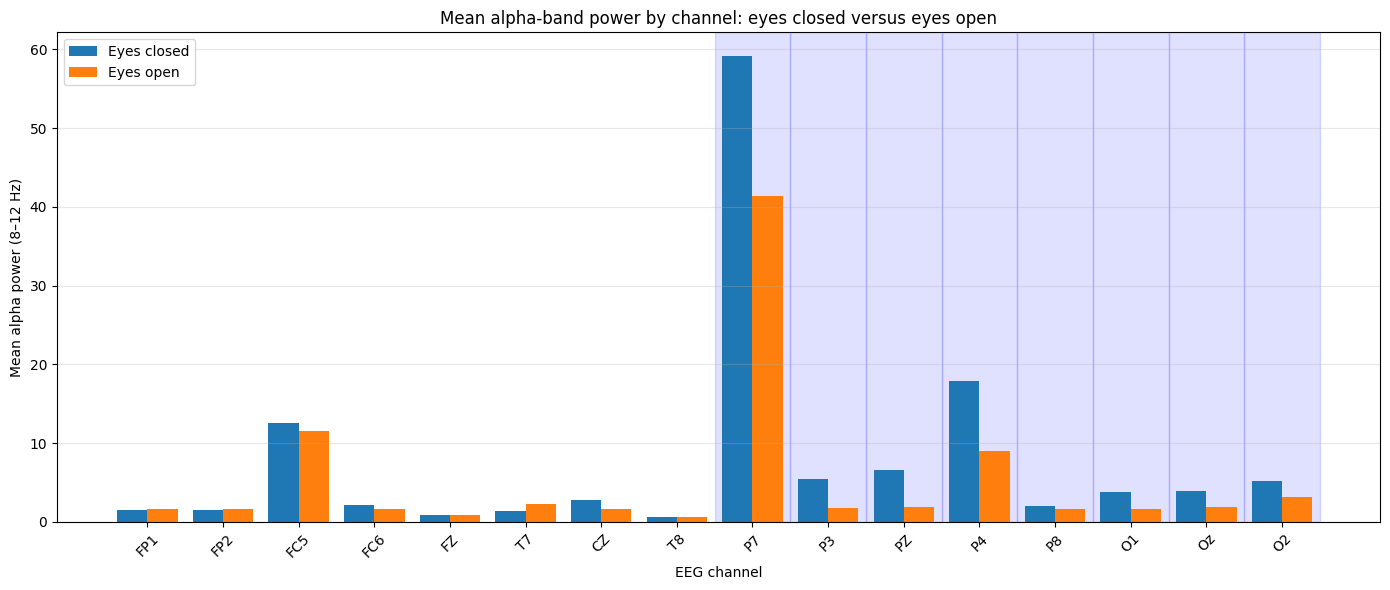

In [ ]:
x = np.arange(len(epochs.ch_names))
width = 0.4

plt.figure(figsize=(14, 6))

posterior_channels = ["P7", "P3", "PZ", "P4", "P8", "O1", "Oz", "O2"]

for channel in posterior_channels:
    channel_index = epochs.ch_names.index(channel)
    plt.axvspan(
        channel_index - 0.5,
        channel_index + 0.5,
        color="blue",
        alpha=0.12
    )

plt.bar(
    x - width / 2,
    closed_alpha_mean,
    width,
    label="Eyes closed"
)

plt.bar(
    x + width / 2,
    open_alpha_mean,
    width,
    label="Eyes open"
)

plt.xticks(
    x,
    epochs.ch_names,
    rotation=45
)

plt.xlabel("EEG channel")
plt.ylabel("Mean alpha power (8–12 Hz)")
plt.title("Mean alpha-band power by channel: eyes closed versus eyes open")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

The shaded region denotes the posterior parietal and occiptal electrodes where eyes-closed alpha power was expected to be greatest.

The eyes-closed alpha power was greater than eyes-open alpha power at  most posterior and occipital electrodes. Particularly, P7 showed the largest alpha power values, while Pz showed the largest increase in alpha power with eyes-closed relative to eyes-open.

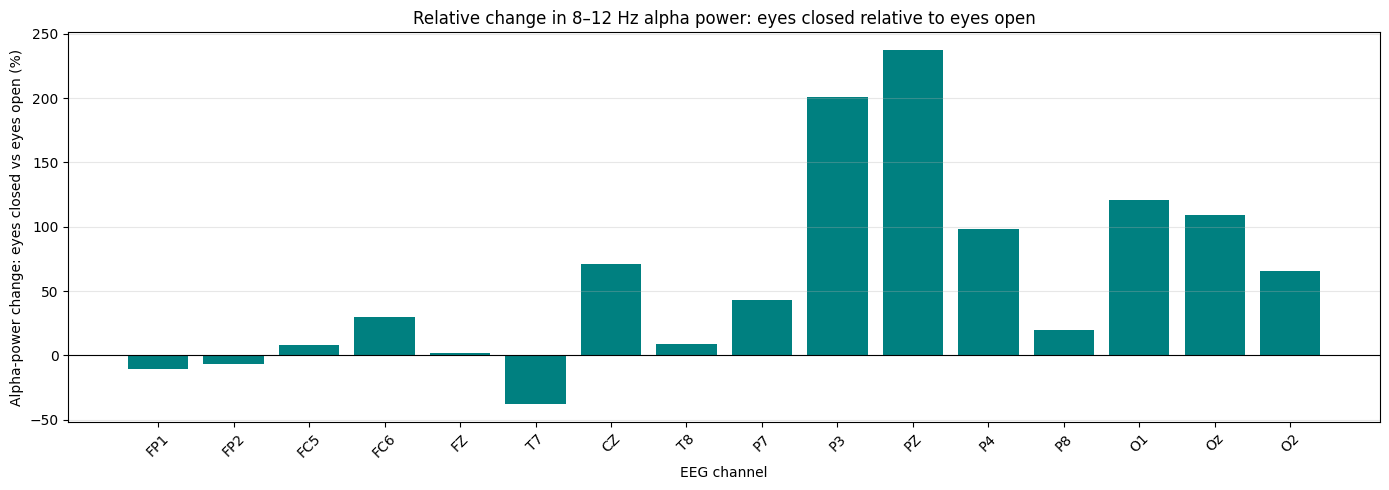

In [ ]:
# Percentage change in mean alpha power from eyes open to eyes closed
relative_alpha_change = (
    (closed_alpha_mean - open_alpha_mean) / open_alpha_mean
) * 100

x = np.arange(len(epochs.ch_names))

plt.figure(figsize=(14, 5))

plt.bar(x, relative_alpha_change, color="teal")

plt.axhline(0, color="black", linewidth=0.8)

plt.xticks(x, epochs.ch_names, rotation=45)
plt.xlabel("EEG channel")
plt.ylabel("Alpha-power change: eyes closed vs eyes open (%)")
plt.title("Relative change in 8–12 Hz alpha power: eyes closed relative to eyes open")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
plt.close()

I can also see from the relative change in alpha power (eyes closed as opposed to open), the parietal and occipital electrodes had the greatest increase, while several in the frontal regions experienced little changed, or even a relative decrease.

Our results are coherent with the Berger effect. However, I have analysed one participant, with only 5 epochs per condition, and a relatively small number of electrodes. Additionally, the dataset units are arbritrary and it is unknown how the headset was physically calibrated.

Finally, I can visually demonstrate the effect through the use of a topological diagram using MNE's built in functions.

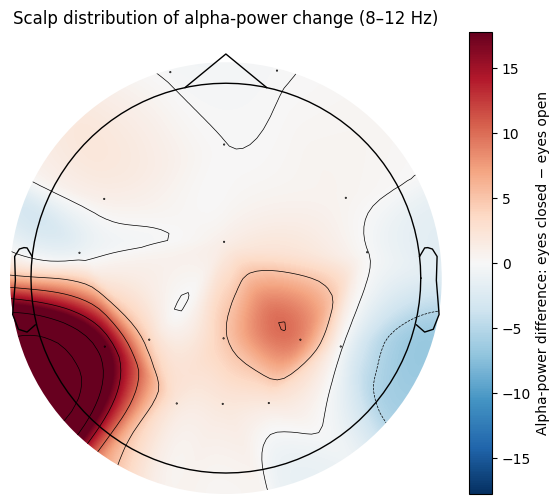

In [ ]:
# Make a copy so the original filtered epochs keep their original labels
epochs_topo = epochs_filtered.copy()

# Rename channels to match MNE's standard_1020 montage naming
rename_map = {
    "FP1": "Fp1",
    "FP2": "Fp2",
    "FZ": "Fz",
    "CZ": "Cz",
    "PZ": "Pz"
}

epochs_topo.rename_channels(rename_map)

# Add standard scalp positions for the EEG channels
epochs_topo.set_montage(
    "standard_1020",
    on_missing="raise"
)

# Alpha-power difference:
# positive = greater alpha power with eyes closed
alpha_difference = closed_alpha_mean - open_alpha_mean

# Match the alpha-power vector to the renamed channel order
# The order is unchanged by renaming, so values still align correctly.
max_abs_difference = np.max(np.abs(alpha_difference))

fig, ax = plt.subplots(figsize=(7, 6))

image, contour = mne.viz.plot_topomap(
    alpha_difference,
    epochs_topo.info,
    axes=ax,
    cmap="RdBu_r",
    vlim=(-max_abs_difference, max_abs_difference),
    contours=6,
    sensors=True,
    show=False
)

fig.colorbar(
    image,
    ax=ax,
    label="Alpha-power difference: eyes closed − eyes open"
)

ax.set_title("Scalp distribution of alpha-power change (8–12 Hz)")

plt.show()
plt.close()

9. Next steps

Despite the evidence of the Berger effect being present, this analysis is only utilising one of the participant datasets, and within this there are a small number of trials. Therefore, I will in the future look to compare different participant data sets, making use of further metadata - the fatigue of the participant, as detailed in the documentation.

This future analysis will aim to identify any links between the potency of the Berger effect and the self-indicated fatigue of the participant. It would also give me practice working with a larger collection of EEG recordings and their associated metadata.

Another possible investigation could be the relationship between the age of the participant and the Berger effect.